In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
DATA_ROOT = '../data'

In [ ]:
/Users/alexanderbroadley/Documents/PhD/Zhang Lab/Zhang_Lab_Code/MML_model/data/

In [6]:
PCC_200_randn_all = pd.read_csv(f'{DATA_ROOT}/HEALTHY_results.csv', index_col= 0, header = 0)
PCC_200_randn_all

,train_loss,test_loss,stopped_early,stopped_epoch,in_features
A2M,0.125009,0.127466,1,12,1068
A2ML1,0.259227,0.238580,1,9,1068
A4GALT,0.140810,0.138494,1,7,1068
AAAS,0.098352,0.096053,1,7,1068
AACS,0.077649,0.070447,1,6,1068
...,...,...,...,...,...
ZYG11A,0.151914,0.154654,1,9,1068
ZYG11B,0.069495,0.063845,1,8,1068
ZYX,0.123225,0.123823,1,8,1068
ZZEF1,0.054711,0.054688,1,7,1068


In [7]:
PCC_200_randn_all['Train'] = 1 - PCC_200_randn_all['train_loss']
PCC_200_randn_all['Test'] = 1 - PCC_200_randn_all['test_loss']

In [8]:
PCC_200_randn_all

,train_loss,test_loss,stopped_early,stopped_epoch,in_features,Train,Test
A2M,0.125009,0.127466,1,12,1068,0.874991,0.872534
A2ML1,0.259227,0.238580,1,9,1068,0.740773,0.761420
A4GALT,0.140810,0.138494,1,7,1068,0.859190,0.861506
AAAS,0.098352,0.096053,1,7,1068,0.901648,0.903947
AACS,0.077649,0.070447,1,6,1068,0.922351,0.929553
...,...,...,...,...,...,...,...
ZYG11A,0.151914,0.154654,1,9,1068,0.848086,0.845346
ZYG11B,0.069495,0.063845,1,8,1068,0.930505,0.936155
ZYX,0.123225,0.123823,1,8,1068,0.876775,0.876177
ZZEF1,0.054711,0.054688,1,7,1068,0.945289,0.945312


In [5]:
External_PCC_200_randn_all = pd.read_csv(f'./data/external_PEARSONS_200_randn_all.csv', index_col=0)
#remove models that did not evaluate
External_PCC_200_randn_all = External_PCC_200_randn_all[~External_PCC_200_randn_all['external_set_score'].isna()]
External_PCC_200_randn_all.columns = ['External PCC']
External_PCC_200_randn_all['External PCC'] = 1 - External_PCC_200_randn_all['External PCC']

KeyError: 'external_set_score'

In [28]:
External_PCC_200_randn_all['External PCC'].describe()

count    2873.000000
mean        0.581899
std         0.276548
min        -0.236299
25%         0.401187
50%         0.666663
75%         0.803614
max         0.961449
Name: External PCC, dtype: float64

<Axes: >

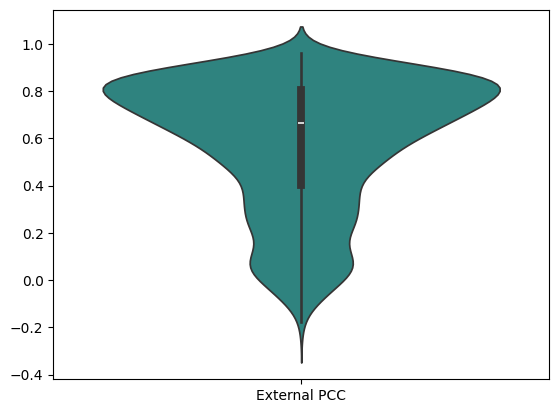

In [29]:
sns.violinplot(data = External_PCC_200_randn_all, palette = 'viridis')


In [5]:
np.sum(PCC_200_randn_all['stopped_early'])

np.float64(10.0)

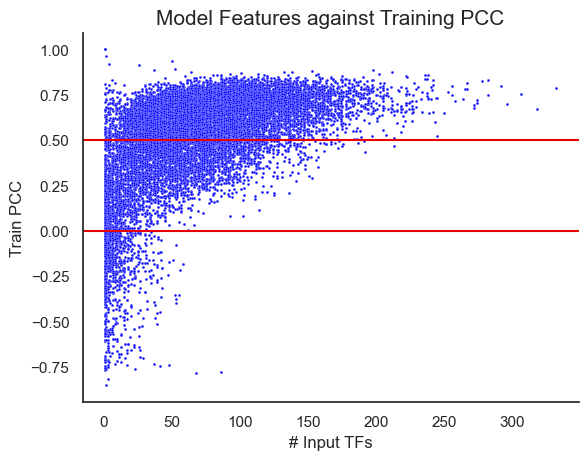

In [ ]:
TPM_res.loc[TPM_res['test_score'] < 0.2, :].shape[0]

In [ ]:
#log_to_plot = pd.melt(logTPM_res)
TPM_to_plot = pd.melt(TPM_res)

In [ ]:
#create function make train test MSE violin plot
def loss_violin_plot(df, palette, title, figtitle):
    fig, ax = plt.subplots()
    ax = sns.violinplot(data = df, x = 'variable', y="value", hue = 'variable', palette=palette)
    ax.set_ylabel('MSE', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
    fig.canvas.draw()
    labels = [item.get_text() for item in ax.get_xticklabels()]
    labels[0], labels[1] = ['Training', 'Test']
    ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
    fig.suptitle(title, fontsize = 20)
    plt.savefig(figtitle, dpi = 300)

/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_8909/1421562481.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Training', 'Test'], fontsize = 10)


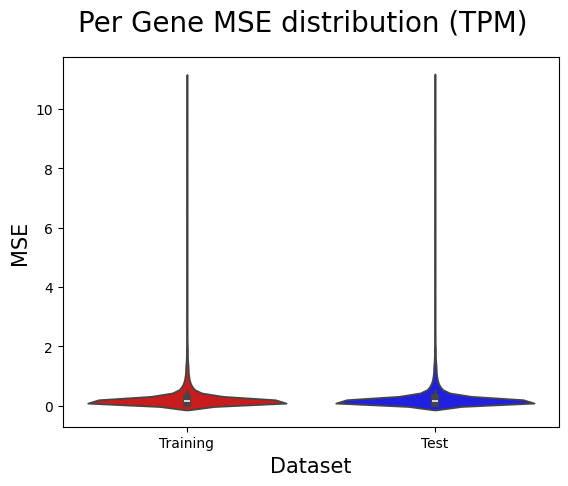

In [ ]:
loss_violin_plot(TPM_to_plot, palette=['#e60000', '#0000ff'], title ='Per Gene MSE distribution (TPM)', figtitle= 'figures/TPM_train_test')

# External dataset erorr scores

ValueError: Could not interpret value `log_external` for `y`. An entry with this name does not appear in `data`.

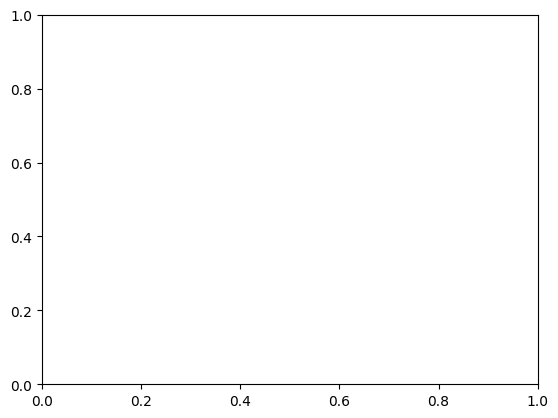

In [ ]:
fig, ax = plt.subplots(ncols=1)

sorted_results = merged_results.sort_values('in_features')
sns.scatterplot(data=sorted_results, x = 'train_score', y = 'log_external', legend=True, ax = ax, hue = 'in_features', palette='icefire', s=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()
ax.set_xlabel('Training Dataset MSE', fontsize = 10)
ax.set_ylabel('Log(External MSE + 1)', fontsize = 10)
fig.suptitle('Training vs External MSE and Model Size')
plt.savefig('figures/trainVSextVSModel', bbox_inches='tight')

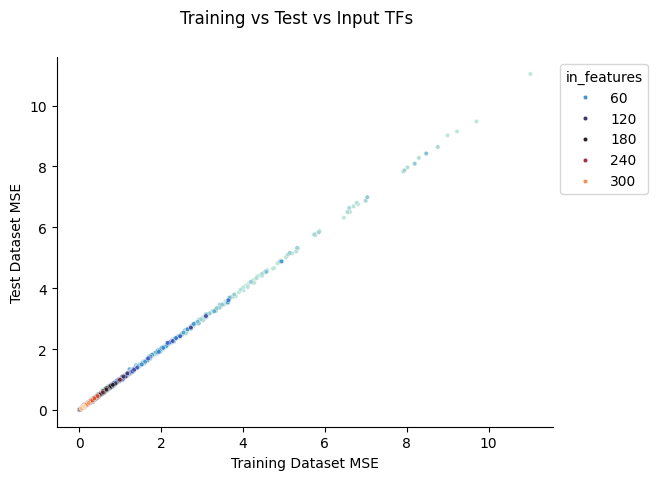

In [ ]:
fig, ax = plt.subplots(ncols=1)

sorted_results = merged_results.sort_values('in_features')
sns.scatterplot(data=sorted_results, x = 'train_score', y = 'test_score', legend=True, ax = ax, hue = 'in_features', palette='icefire', s=10)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()
ax.set_xlabel('Training Dataset MSE', fontsize = 10)
ax.set_ylabel('Test Dataset MSE', fontsize = 10)
fig.suptitle('Training vs Test vs Input TFs')
plt.savefig('figures/trainVsTestvsModel', bbox_inches='tight')

In [ ]:
external_res.loc[external_res['external_set_score'] < 1].shape

(13446, 2)

In [ ]:
external_res['log'] = np.log(external_res['external_set_score'] + 1)

/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_88664/1795373650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data = external_res, y="log", palette=['#e60000'])


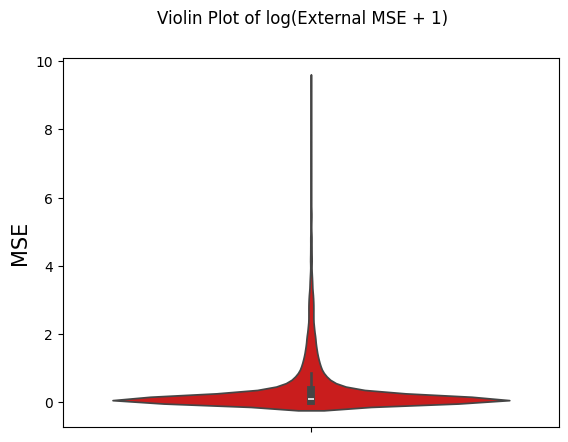

In [ ]:
fig, ax = plt.subplots()
ax = sns.violinplot(data = external_res, y="log", palette=['#e60000'])
ax.set_ylabel('MSE', fontsize = 15)
fig.suptitle('Violin Plot of log(External MSE + 1)')
plt.show()
#ax.set_xlabel('Dataset', fontsize = 15)
#fig.canvas.draw()
#labels = [item.get_text() for item in ax.get_xticklabels()]
#labels[0], labels[1] = ['Training', 'Test']
#ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
#fig.suptitle(title, fontsize = 20)
#plt.savefig(figtitle, dpi = 300)

# Correlation and MSE plots

In [14]:
def create_pearsons_violin(results_df, y_col, title, file_title, figure_root = './figures', **kwargs):
    '''
    Taking a results df with two columns ['pearsons', 'dataset'] 
    Plots the pearsons values by dataset of origin as violin plots and saves figure with specified file_title at figure_root

    Parameters
    ---------------
    results_df : pandas dataframe
        dataframe containg the results to plot. Must contain a categorical column called dataset to serve as x axis categories
    y_col : string
        name of column in results df with statistic to make violin plot for 
    title : string
        title to display on plot
    file_title : string
        filename of saved figure
    figure_root : string
        path to directory in which to save the figure

    Returns
    --------------
    None
        Saves figure to desired location
    '''
    #store all plot formating arguments in dictionary - kwargs can then override
    plot_defaults = {'ylim':(-1, 1),
                     'palette':'viridis'}

    plot_kwargs = {**plot_defaults, **kwargs}

    #violin_plot_arguments = list(inspect.signature(sns.violinplot).parameters.keys())

    savepath = f'{figure_root}/{file_title}'

    fig, ax = plt.subplots()
    
    ax = sns.violinplot(data = results_df, x = 'dataset', y= y_col, hue = 'dataset', palette=plot_kwargs['palette'])

    if y_col == 'pearsons':
        ax.set_ylabel('Pearsons R', fontsize = 15)
    elif y_col == 'spearmans':
        ax.set_ylabel('Spearmans Rank', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
   
    plt.ylim(plot_kwargs['ylim'])
    fig.suptitle(title, fontsize = 20)
    plt.savefig(savepath, dpi = 300, bbox_inches = 'tight')

In [9]:
from_train_losses = PCC_200_randn_all[['Train', 'Test']].melt()
from_train_losses.columns = ['dataset', 'value']

In [19]:
PCC_200_randn_all['Test'].describe()

count    15212.000000
mean         0.835508
std          0.111854
min          0.172523
25%          0.788760
50%          0.871873
75%          0.916990
max          0.966636
Name: Test, dtype: float64

In [22]:
from_train_losses

,dataset,value
0,Train,0.874991
1,Train,0.740773
2,Train,0.859190
3,Train,0.901648
4,Train,0.922351
...,...,...
30419,Test,0.845346
30420,Test,0.936155
30421,Test,0.876177
30422,Test,0.945312


In [ ]:
from_train_losses['value'] = 1 - from_train_losses['value']

In [ ]:
genewise_correlations['LogMSE'] = np.log(genewise_correlations['MSE']+1)

In [16]:
from_train_losses

,dataset,value
0,Train,0.874991
1,Train,0.740773
2,Train,0.859190
3,Train,0.901648
4,Train,0.922351
...,...,...
30419,Test,0.845346
30420,Test,0.936155
30421,Test,0.876177
30422,Test,0.945312


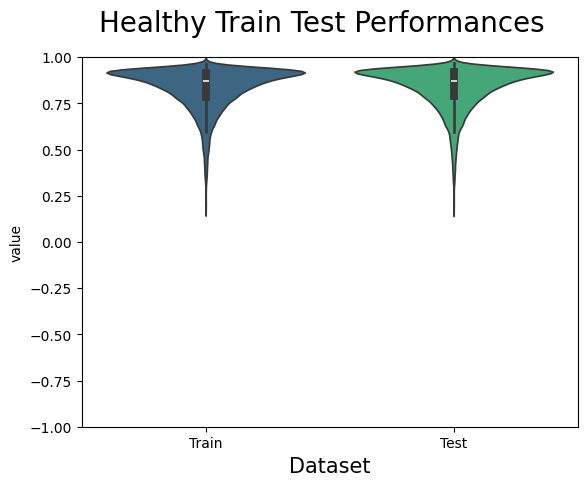

In [17]:

create_pearsons_violin(from_train_losses, y_col = 'value', title = 'Healthy Train Test Performances', file_title = 'Healthy_train_test')